# Imports

In [1]:
import numpy as np
import pandas as pd

import sklearn as sk
from sklearn import base
from sklearn import calibration
from sklearn import cluster
from sklearn import compose
from sklearn import covariance
from sklearn import cross_decomposition
from sklearn import datasets
from sklearn import decomposition
from sklearn import discriminant_analysis
from sklearn import dummy
from sklearn import ensemble
from sklearn import exceptions
from sklearn import experimental
from sklearn import feature_extraction
from sklearn import feature_selection
from sklearn import gaussian_process
from sklearn import impute
from sklearn import inspection
from sklearn import isotonic
from sklearn import kernel_approximation
from sklearn import kernel_ridge
from sklearn import linear_model
from sklearn import manifold
from sklearn import metrics
from sklearn import mixture
from sklearn import model_selection
from sklearn import multiclass
from sklearn import multioutput
from sklearn import naive_bayes
from sklearn import neighbors
from sklearn import neural_network
from sklearn import pipeline
from sklearn import preprocessing
from sklearn import random_projection
from sklearn import semi_supervised
from sklearn import svm
from sklearn import tree
from sklearn import utils

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Analisi

## Es. 1

In [2]:
df = pd.read_csv('dataset.csv', sep=',')
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [3]:
print('Rows (instances):', df.shape[0])

Rows (instances): 32561


In [4]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

Vere e proprie missing values non ce ne sono, ma ci sono dati non specificati.

In [5]:
(df == '?').sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [6]:
df['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

La colonna target non è bilanciata.

## Es. 2

In [7]:
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

In [8]:
dfmin40 = df[(df['education'].isin(['Bachelors', 'Masters', 'Doctorate'])) & (df['age'] < 40)].copy()
dfmin40['income'].mean()

np.float64(0.3437250199840128)

In [9]:
dfmag40 = df[(df['education'].isin(['Bachelors', 'Masters', 'Doctorate'])) & (df['age'] >= 40)].copy()
dfmag40['income'].mean()

np.float64(0.5874799357945425)

La probabilità per quelli con età inferiore a 40 è minore.

## Es. 3

In [10]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,0
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,0
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,0
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,0
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,0
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0


In [11]:
m = df['hours.per.week'].max()
m

99

In [12]:
df['hours.per.week'] = pd.cut(df['hours.per.week'], [0, 30, 50, m])
df['hours.per.week'].value_counts()

hours.per.week
(30, 50]    23673
(0, 30]      5245
(50, 99]     3643
Name: count, dtype: int64

In [13]:
pt = df.pivot_table(values='income', index='hours.per.week', columns='sex', aggfunc='mean')
pt

/var/folders/ph/t7gwl3k17_l0cxktc3ll17600000gn/T/ipykernel_35424/4161802699.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pt = df.pivot_table(values='income', index='hours.per.week', columns='sex', aggfunc='mean')


sex,Female,Male
hours.per.week,,
"(0, 30]",0.060228,0.074941
"(30, 50]",0.120240,0.314060
"(50, 99]",0.204263,0.450974


Si, chi lavora più ore ha sempre un reddito più alto. Gli uomini hanno una probabilità maggiore di avere un income >50K rispetto alle donne a parità di fascia oraria.

## Es. 4

In [14]:
dfmin = df[df['income'] == 0].copy()
dfmag = df[df['income'] == 1].copy()

In [15]:
print(dfmin['capital.gain'].mean())
print(dfmin['capital.gain'].median())
print(dfmag['capital.gain'].mean())
print(dfmag['capital.gain'].median())

148.75246763754046
0.0
4006.142456319347
0.0


<Axes: >

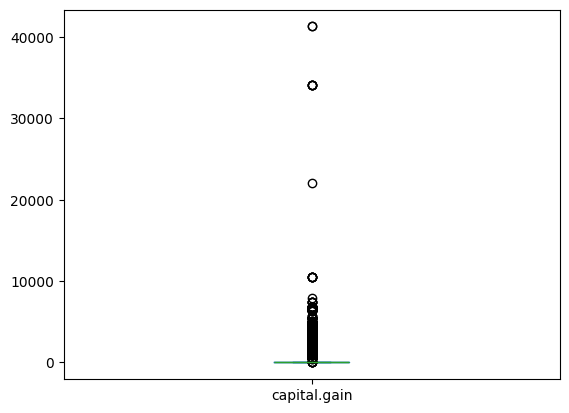

In [16]:
dfmin['capital.gain'].plot(kind='box')

<Axes: >

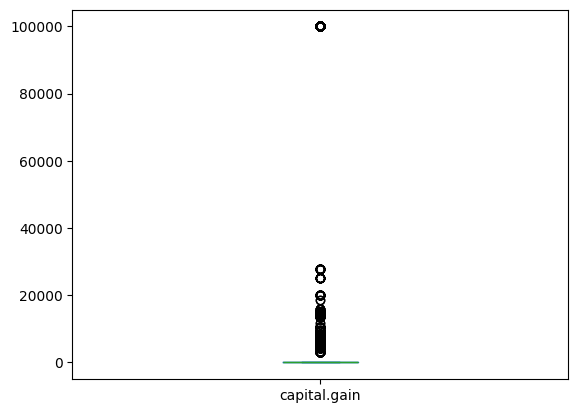

In [17]:
dfmag['capital.gain'].plot(kind='box')

# Trasformazione e predizione

## Es. 1

In [18]:
df = pd.read_csv('dataset.csv', sep=',')
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


Per fairness, elimino la feature 'race'.

In [19]:
df = df.drop('race', axis=1)
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,Female,0,0,40,United-States,<=50K


In [20]:
df = df.dropna()
df = df.drop_duplicates()
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,Female,0,0,40,United-States,<=50K


In [21]:
cat_features = [col for col in df.columns if df[col].dtype == object]
cat_features.remove('income')
ord_enc = preprocessing.OrdinalEncoder()
ord_enc.fit(df.loc[:, cat_features])
enc_features = ord_enc.transform(df.loc[:, cat_features])
df.loc[:, cat_features] = enc_features
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,0.0,77053,11.0,9,6.0,0.0,1.0,0.0,0,4356,40,39.0,<=50K
1,82,4.0,132870,11.0,9,6.0,4.0,1.0,0.0,0,4356,18,39.0,<=50K
2,66,0.0,186061,15.0,10,6.0,0.0,4.0,0.0,0,4356,40,39.0,<=50K
3,54,4.0,140359,5.0,4,0.0,7.0,4.0,0.0,0,3900,40,39.0,<=50K
4,41,4.0,264663,15.0,10,5.0,10.0,3.0,0.0,0,3900,40,39.0,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,4.0,310152,15.0,10,4.0,11.0,1.0,1.0,0,0,40,39.0,<=50K
32557,27,4.0,257302,7.0,12,2.0,13.0,5.0,0.0,0,0,38,39.0,<=50K
32558,40,4.0,154374,11.0,9,2.0,7.0,0.0,1.0,0,0,40,39.0,>50K
32559,58,4.0,151910,11.0,9,6.0,1.0,4.0,0.0,0,0,40,39.0,<=50K


In [22]:
lab_enc = preprocessing.LabelEncoder()
df['income'] = lab_enc.fit_transform(df['income'])
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,0.0,77053,11.0,9,6.0,0.0,1.0,0.0,0,4356,40,39.0,0
1,82,4.0,132870,11.0,9,6.0,4.0,1.0,0.0,0,4356,18,39.0,0
2,66,0.0,186061,15.0,10,6.0,0.0,4.0,0.0,0,4356,40,39.0,0
3,54,4.0,140359,5.0,4,0.0,7.0,4.0,0.0,0,3900,40,39.0,0
4,41,4.0,264663,15.0,10,5.0,10.0,3.0,0.0,0,3900,40,39.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,4.0,310152,15.0,10,4.0,11.0,1.0,1.0,0,0,40,39.0,0
32557,27,4.0,257302,7.0,12,2.0,13.0,5.0,0.0,0,0,38,39.0,0
32558,40,4.0,154374,11.0,9,2.0,7.0,0.0,1.0,0,0,40,39.0,1
32559,58,4.0,151910,11.0,9,6.0,1.0,4.0,0.0,0,0,40,39.0,0


In [23]:
lab_enc.classes_

array(['<=50K', '>50K'], dtype=object)

In [24]:
ord_enc.categories_

[array(['?', 'Federal-gov', 'Local-gov', 'Never-worked', 'Private',
        'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay'],
       dtype=object),
 array(['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th',
        'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Doctorate', 'HS-grad',
        'Masters', 'Preschool', 'Prof-school', 'Some-college'],
       dtype=object),
 array(['Divorced', 'Married-AF-spouse', 'Married-civ-spouse',
        'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed'],
       dtype=object),
 array(['?', 'Adm-clerical', 'Armed-Forces', 'Craft-repair',
        'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners',
        'Machine-op-inspct', 'Other-service', 'Priv-house-serv',
        'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support',
        'Transport-moving'], dtype=object),
 array(['Husband', 'Not-in-family', 'Other-relative', 'Own-child',
        'Unmarried', 'Wife'], dtype=object),
 array(['Female', 'Male'], d

In [25]:
X = df.drop(['income'], axis=1)
y = df['income']
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.25, stratify=y)

In [26]:
def evaluate_model(model):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    print(model)
    print("F1 Score train:", metrics.f1_score(y_train, y_train_pred))
    print("F1 Score test:", metrics.f1_score(y_test, y_test_pred))
    print('Confusion matrix train\n', metrics.confusion_matrix(y_train, y_train_pred))
    print('Confusion matrix test\n', metrics.confusion_matrix(y_test, y_test_pred))
    print()

treeclf = tree.ExtraTreeClassifier(random_state=0)
kn = neighbors.KNeighborsClassifier()
dum = dummy.DummyClassifier(strategy='stratified', random_state=0)
evaluate_model(treeclf)
evaluate_model(kn)
evaluate_model(dum)

ExtraTreeClassifier(random_state=0)
F1 Score train: 0.999914944288509
F1 Score test: 0.5903890160183066
Confusion matrix train
 [[18523     0]
 [    1  5878]]
Confusion matrix test
 [[5363  812]
 [ 799 1161]]

KNeighborsClassifier()
F1 Score train: 0.5621251071122536
F1 Score test: 0.4233387358184765
Confusion matrix train
 [[17690   833]
 [ 3255  2624]]
Confusion matrix test
 [[5703  472]
 [1307  653]]

DummyClassifier(random_state=0, strategy='stratified')
F1 Score train: 0.23419442556084297
F1 Score test: 0.23965029570583699
Confusion matrix train
 [[14012  4511]
 [ 4501  1378]]
Confusion matrix test
 [[4712 1463]
 [1494  466]]



Il classificatore migliore è l'ExtraTreeTlassifier. Il KNeighbours perde performance perché tende a predire con maggiore probabilità la classe positiva.

In ogni caso entrambi performano meglio del dummy classifier.

## Es. 2

In [27]:
y_pred = treeclf.predict(X_test)
X_test['pred'] = y_pred
X_test

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,pred
19468,39,4.0,28572,11.0,9,4.0,6.0,3.0,1.0,0,0,48,39.0,0
24892,50,4.0,167065,9.0,13,2.0,4.0,0.0,1.0,0,0,40,39.0,1
1917,38,0.0,70282,12.0,14,2.0,0.0,5.0,0.0,15024,0,2,39.0,1
26663,67,4.0,105252,12.0,14,2.0,4.0,0.0,1.0,0,0,40,39.0,1
12094,28,1.0,56651,9.0,13,4.0,10.0,3.0,0.0,0,0,40,39.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32188,37,4.0,338033,12.0,14,4.0,10.0,1.0,0.0,0,0,40,39.0,0
29412,52,4.0,206862,11.0,9,2.0,3.0,0.0,1.0,0,0,40,39.0,1
22807,43,2.0,92374,12.0,14,2.0,10.0,5.0,0.0,0,0,35,39.0,1
1946,39,4.0,33983,15.0,10,2.0,1.0,0.0,1.0,15024,0,40,39.0,1


In [28]:
men = X_test[X_test['sex'] == 1]
women = X_test[X_test['sex'] == 0]
prob_man = men[men['pred']==1].shape[0] / men.shape[0]
prob_woman = women[women['pred']==1].shape[0] / women.shape[0]

print('Probabilità reddito >50K per gli uomini: {}'.format(prob_man))
print('Probabilità reddito >50K per le donne: {}'.format(prob_woman))

Probabilità reddito >50K per gli uomini: 0.3108635097493036
Probabilità reddito >50K per le donne: 0.10872727272727273


In [29]:
X_test['real'] = y_test.values

f1_men = metrics.f1_score(X_test[X_test['sex']==1]['real'], men['pred'])
f1_women = metrics.f1_score(X_test[X_test['sex']==0]['real'], women['pred'])
cm_men = metrics.confusion_matrix(X_test[X_test['sex']==1]['real'], men['pred'])
cm_women = metrics.confusion_matrix(X_test[X_test['sex']==0]['real'], women['pred'])
print('F1 sugli uomini:', f1_men)
print('F1 sulle donne:', f1_women)
print('F1 sugli uomini:', cm_men)
print('F1 sulle donne:', cm_women)

F1 sugli uomini: 0.6126718469814704
F1 sulle donne: 0.46337308347529815
F1 sugli uomini: [[3064  649]
 [ 647 1025]]
F1 sulle donne: [[2299  163]
 [ 152  136]]


In [30]:
X_test = X_test.drop(['real', 'pred'], axis=1)

index_men = X_test[X_test['sex']==1].index
index_women = X_test[X_test['sex']==0].index

In [31]:
X_train = X_train.drop('sex', axis=1)
X_test = X_test.drop('sex', axis=1)

treeclf.fit(X_train, y_train)
y_pred = treeclf.predict(X_test)

X_test['real'] = y_test
X_test['pred'] = y_pred

f1_men = metrics.f1_score(X_test.loc[index_men]['real'], X_test.loc[index_men]['pred'])
f1_women = metrics.f1_score(X_test.loc[index_women]['real'], X_test.loc[index_women]['pred'])
cm_men = metrics.confusion_matrix(X_test.loc[index_men]['real'], X_test.loc[index_men]['pred'])
cm_women = metrics.confusion_matrix(X_test.loc[index_women]['real'], X_test.loc[index_women]['pred'])

acc_men = metrics.accuracy_score(X_test.loc[index_men]['real'], X_test.loc[index_men]['pred'])
acc_women = metrics.accuracy_score(X_test.loc[index_women]['real'], X_test.loc[index_women]['pred'])

print('F1 sugli uomini:', f1_men)
print('F1 sulle donne:', f1_women)
print('F1 sugli uomini:', cm_men)
print('F1 sulle donne:', cm_women)

F1 sugli uomini: 0.6208574034660991
F1 sulle donne: 0.4472843450479233
F1 sugli uomini: [[3117  596]
 [ 651 1021]]
F1 sulle donne: [[2264  198]
 [ 148  140]]


Si ha un F1 score migliore sugli uomini sia con la colonna sex, sia senza, e gli score sono molto simili fra loro.

La colonna sex non influisce in modo significativo sulla predizione.

## Es. 3

In [32]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,0.0,77053,11.0,9,6.0,0.0,1.0,0.0,0,4356,40,39.0,0
1,82,4.0,132870,11.0,9,6.0,4.0,1.0,0.0,0,4356,18,39.0,0
2,66,0.0,186061,15.0,10,6.0,0.0,4.0,0.0,0,4356,40,39.0,0
3,54,4.0,140359,5.0,4,0.0,7.0,4.0,0.0,0,3900,40,39.0,0
4,41,4.0,264663,15.0,10,5.0,10.0,3.0,0.0,0,3900,40,39.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,4.0,310152,15.0,10,4.0,11.0,1.0,1.0,0,0,40,39.0,0
32557,27,4.0,257302,7.0,12,2.0,13.0,5.0,0.0,0,0,38,39.0,0
32558,40,4.0,154374,11.0,9,2.0,7.0,0.0,1.0,0,0,40,39.0,1
32559,58,4.0,151910,11.0,9,6.0,1.0,4.0,0.0,0,0,40,39.0,0


In [33]:
X = df.drop(['income'], axis=1)
y = df['income']
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.25, stratify=y)
X

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country
0,90,0.0,77053,11.0,9,6.0,0.0,1.0,0.0,0,4356,40,39.0
1,82,4.0,132870,11.0,9,6.0,4.0,1.0,0.0,0,4356,18,39.0
2,66,0.0,186061,15.0,10,6.0,0.0,4.0,0.0,0,4356,40,39.0
3,54,4.0,140359,5.0,4,0.0,7.0,4.0,0.0,0,3900,40,39.0
4,41,4.0,264663,15.0,10,5.0,10.0,3.0,0.0,0,3900,40,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,4.0,310152,15.0,10,4.0,11.0,1.0,1.0,0,0,40,39.0
32557,27,4.0,257302,7.0,12,2.0,13.0,5.0,0.0,0,0,38,39.0
32558,40,4.0,154374,11.0,9,2.0,7.0,0.0,1.0,0,0,40,39.0
32559,58,4.0,151910,11.0,9,6.0,1.0,4.0,0.0,0,0,40,39.0


In [34]:
params = {
    'criterion': ["gini", "entropy", "log_loss"],
    'max_depth': [5, 10, 15, 20, None]
}

gridsearch = model_selection.GridSearchCV(estimator=treeclf, param_grid=params, scoring='f1', cv=5)
gridsearch.fit(X_train, y_train)
print('CV results\n', gridsearch.cv_results_)
print('Best params:', gridsearch.best_params_)
print('Best estimator:', gridsearch.best_estimator_)
print('Best score:', gridsearch.best_score_)

y_pred = gridsearch.predict(X_test)
print("F1 Score test:", metrics.f1_score(y_test, y_pred))
print('Confusion matrix test\n', metrics.confusion_matrix(y_test, y_pred))

CV results
 {'mean_fit_time': array([0.00743303, 0.00810523, 0.00917978, 0.01019678, 0.01148129,
       0.00714641, 0.00801058, 0.00909386, 0.00995035, 0.0119525 ,
       0.00704799, 0.00790019, 0.00892868, 0.01003904, 0.01187367]), 'std_fit_time': array([4.63640679e-04, 1.17217728e-04, 2.58845789e-04, 2.55961265e-04,
       2.17808284e-04, 1.29655732e-04, 9.59405842e-05, 1.83348978e-04,
       8.81846350e-05, 1.74222073e-04, 7.94914287e-05, 1.23831351e-04,
       1.97401461e-04, 1.38970866e-04, 2.25238381e-04]), 'mean_score_time': array([0.00221238, 0.00221558, 0.00234656, 0.00242801, 0.00249624,
       0.00209312, 0.00215459, 0.00224152, 0.00232439, 0.00249052,
       0.00203295, 0.00211816, 0.00217676, 0.00233674, 0.00249825]), 'std_score_time': array([1.50360117e-04, 2.09631629e-05, 1.27755469e-04, 3.04696332e-05,
       3.60745510e-05, 9.51745228e-05, 2.67598702e-05, 2.11183420e-05,
       5.89387702e-05, 2.69309589e-05, 5.73418046e-05, 4.24329883e-05,
       4.73561960e-05, 3.484

Le performance sono pressoché invariate.

## Es. 4

In [35]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,0.0,77053,11.0,9,6.0,0.0,1.0,0.0,0,4356,40,39.0,0
1,82,4.0,132870,11.0,9,6.0,4.0,1.0,0.0,0,4356,18,39.0,0
2,66,0.0,186061,15.0,10,6.0,0.0,4.0,0.0,0,4356,40,39.0,0
3,54,4.0,140359,5.0,4,0.0,7.0,4.0,0.0,0,3900,40,39.0,0
4,41,4.0,264663,15.0,10,5.0,10.0,3.0,0.0,0,3900,40,39.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,4.0,310152,15.0,10,4.0,11.0,1.0,1.0,0,0,40,39.0,0
32557,27,4.0,257302,7.0,12,2.0,13.0,5.0,0.0,0,0,38,39.0,0
32558,40,4.0,154374,11.0,9,2.0,7.0,0.0,1.0,0,0,40,39.0,1
32559,58,4.0,151910,11.0,9,6.0,1.0,4.0,0.0,0,0,40,39.0,0


In [36]:
preprocessor = compose.ColumnTransformer(transformers=[('discr', preprocessing.KBinsDiscretizer(n_bins=5), ['age', 'hours.per.week']),
                                                  ('scale', preprocessing.MinMaxScaler((0,1)), ['capital.gain', 'capital.loss'])],
                                    remainder='passthrough')

model = tree.ExtraTreeClassifier(**gridsearch.best_params_)
print(model)

my_pipeline = pipeline.Pipeline(steps=[('preprocessor', preprocessor),
                                    ('model', model)])

my_pipeline.fit(X=X_train, y=y_train)

y_pred = my_pipeline.predict(X=X_test)
print("F1 Score test:", metrics.f1_score(y_test, y_pred))
print('Confusion matrix test\n', metrics.confusion_matrix(y_test, y_pred))

ExtraTreeClassifier(max_depth=20)
F1 Score test: 0.5890002709292874
Confusion matrix test
 [[5531  644]
 [ 873 1087]]


/opt/anaconda3/envs/BDTA/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(


Le performance sono pressoché invariate.

## Es. 5

In [37]:
df = pd.read_csv('dataset.csv', sep=',')
X = df.drop(['income', 'race'], axis=1)
df['income'] = lab_enc.fit_transform(df['income'])
y = df['income']

categorical_features = [col for col in X.columns if X[col].dtype == object]
numerical_features = [col for col in X.columns if X[col].dtype in ['int64', 'float64']]

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.25, stratify=y)

In [38]:
preprocessor = compose.ColumnTransformer(transformers=[('encode', preprocessing.OneHotEncoder(handle_unknown='ignore'), categorical_features),
                                                  ('std', preprocessing.StandardScaler(), numerical_features)],
                                                  remainder='passthrough')

model = tree.ExtraTreeClassifier(random_state=0)

my_pipeline2 = pipeline.Pipeline(steps=[('preprocessor', preprocessor),
                                       ('estimator', model)])

my_pipeline2.fit(X=X_train, y=y_train)

y_pred = my_pipeline2.predict(X=X_test)
print("F1 Score test:", metrics.f1_score(y_test, y_pred))
print('Confusion matrix test\n', metrics.confusion_matrix(y_test, y_pred))

F1 Score test: 0.5831423478482302
Confusion matrix test
 [[5359  822]
 [ 815 1145]]


Le performance sono pressoché invariate.

## Es. 6

In [39]:
my_pipeline3 = pipeline.Pipeline(steps=[('preprocessor', preprocessor),
                                       ('select', feature_selection.SelectKBest()),
                                       ('estimator', model)])

parameters = {
    'select__k': [2,4,6],
    'estimator__criterion': ["gini", "entropy", "log_loss"],
    'estimator__max_depth': [5, 10, 15, None],
}

gridsearch2 = model_selection.GridSearchCV(my_pipeline3, parameters, scoring='f1', cv=5, n_jobs=-1)

gridsearch2.fit(X_train, y_train)
print('Best params:', gridsearch2.best_params_)
print('Best estimator:', gridsearch2.best_estimator_)
print('Best score:', gridsearch2.best_score_)

y_pred = gridsearch2.predict(X_test)
print("F1 Score test:", metrics.f1_score(y_test, y_pred))
print('Confusion matrix test\n', metrics.confusion_matrix(y_test, y_pred))

Best params: {'estimator__criterion': 'gini', 'estimator__max_depth': 15, 'select__k': 6}
Best estimator: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encode',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass', 'education',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'sex', 'native.country']),
                                                 ('std', StandardScaler(),
                                                  ['age', 'fnlwgt',
                                                   'education.num',
                                                   'capital.gain',
                                                   'capital.loss',
 

Le performance peggiorano leggermente.